# Quick Start Guide

This guide will go through the basics of setting up and running fits with `Alfred`. It will teach you how to set up a directory for an exoplanet system, and then run transit and RV fits. This guide will use example data provided with the installation of `Alfred`, stored in `alfred.data_dir`, but you can follow along using your own data as well.

We will start by importing `alfred`, along with setting the way our plots will be displayed (for the purposes of this guide).

In [1]:
import alfred

import matplotlib
matplotlib.use('inline')

The first thing we need to do is create a directory to store our data, initialization files, and results for this system. `Alfred` has a built in function to guide you through this and generate the required directory structure and initialization files for it to run. It will prompt you in order to fill in the initialization files.

If you are following along using the example data, first check on the path to the directory by printing `alfred.data_dir`.

In [2]:
alfred.data_dir

'/home/kroft/Python/Alfred/alfred/example_data/'

Let's first set a directory path, then run `alfred.create_folder`. Replace direc with your own directory path where you want this to be.

If you are following along using the example data use the responses below under the spoiler. You can also check on the system parameters used to generate the data in the true_parameters.csv file in the data_dir.

<details>
<summary>Click here to show create_folder prompt responses for the example data set</summary>

**Light Curve Initialization**

* After creating the directory, you will be prompted on whether or not you already have the light curve files on hand. Answer y.

* You will get a message confirming that you are creating the init_lcs.txt file in your chosen directory. Enter to continue.

* Next, when asked about the path to the light curve file, paste in the `alfred.data_dir` from above and add "lc_example.csv" at the end. That file will be copied into your new directory.

* Give the dataset a nickname, I will be using "ex_lc". This will be used during fits to assign variable names for that data set, such as F0 (the baseline flux).

* For time data column header, enter "t".

* For flux data column header, enter "f".

* For flux error data column header, enter "ferr".

* Enter "None" for the quality flag column, since this fake data doesn't have one.

* The time offset from BJD is "2450000" for this example data set.

* The exposure time, or cadence, is 120 seconds.

* This is fake TESS data, so enter "TESS". This will be used to assign the correct limb darkening parameters for the data set.

* We do not need to detrend this light curve, so enter "False".

* We do not have more light curve files, so enter "n".

**Limb Darkening Initialization**

* You should now have a message confirming that you are creating the init_ld.txt file. Enter to continue.

* We are going to manually enter the quadratic limb darkening parameters. Enter "n".

* We will do this for the "TESS" filter, which we assigned to our data set.

* The first limb darkening parameter is "0.415".

* The second limb darkening parameter is "0.1974".

* We do not have any more filters, enter "n".

**RV Initialization**

* We do have the rv file already, in the example data. Enter "y".

* You will have a message confirming you are creating the init_rv.txt file. Enter to continue.

* Once again, paste in the `alfred.data_dir` path and add "rv_example.csv" this time.

* Give the data set a nickname, I will use "ex_rv".

* The time data column header is "t".

* The RV data column header is "rv".

* The RV error data column header is "rverr".

* The time offset from BJD is "2450000" again.

* The fake RVs are in "m/s".

* We do not have more RV files, so enter "n".

**Star Initialization**

* You should have a message confirming you are creating the init_star.txt file. Enter to continue.

* We now need to enter the stellar radius and its uncertainty in solar radii, separated by a space. Enter "0.826 0.035".

* We do the same for the stellar mass, enter "0.891 0.031".

* We do the same for the stellar effective temperature, enter "5197 50".

* We do the same for logg, enter "4.496 0.1".

* We do the same for Fe/H, enter "0.044 0.08".

* Assuming astroquery is up and running, we will get the Gaia parallax and photometric magnitudes using astroquery. This fake system actually uses the stellar information for TIC 238279960. Enter "y".

* Enter "TIC 238279960" for the catalog ID. If this does not work, you will have to manually enter values that you find by searching for this target in catalogs. For the purposes of following along here, they do not matter and you can type whatever you want. They will matter, however, if you are fitting stellar parameters.

**Planet Initialization**

* You should now have a message confirming you are creating the init_planets.txt file. Enter to continue.

* The fake planet is transiting, enter "True".

* The fake planet does have an RV signal, enter "True".

* We do not want to fit TTVs, enter "False".

* We also do not want to fit a secondary eclipse, enter "False".

* We do want to fit eccentricity, enter "True".

* Our initial guess at the planet period will be "3.1" days.

* Our initial guess at the time of conjunction will be "10001".

* Our initial guess at the planet-to-star radius ratio will be "0.1".

* Our initial guess at the semimajor axis to stellar radius ratio will be "10".

* Our intial guess at the cosine of the inclination will be "0.01".

* Our initial guess at the rv semi-amplitude will be "150".

* Our initial guess at the sqrt(e)cos(w) term will be "0.1".

* Our initial guess at the sqrt(e)sin(w) term will be "0.1".

* There are no more planets in our fake system, so enter "n".

**You should be all done now with setting up the directory, go check it out!**
</details>

In [3]:
direc = '/mnt/c/Users/kroft/Documents/alfred_example/'

In [4]:
alfred.create_folder(direc)

Now that we have our directory set up, we can initialize an ``alfred.ExoSystem`` object from the directory. This will store all of the data and initialization parameters, and we will be able to run our fits and make plots using the object's functions.

In [5]:
exs = alfred.ExoSystem(direc)

Now we are ready to run a fit. Lets pick a name for our fit, I will call mine "example". Then we can run ``exs.fit``. We need to set a few required parameters, and there are tons more optional parameters we won't cover here. If you want to learn more about how MCMC fitting works, check out the ``emcee`` docs [here](https://emcee.readthedocs.io/en/stable/).


Initial parameters:
{'log(P) 1': 1.1314021114911006, 'Tc 1': 10001.0, 'ror 1': 0.1, 'log(a/rs) 1': 2.302585092994046, 'cos(i) 1': 0.01, 'log(K) 1': 5.0106352940962555, 'secw 1': 0.1, 'sesw 1': 0.1, 'F0 lc_ex': 1.0, 'gamma': 0}

Starting sigma clipping of lightcurves.


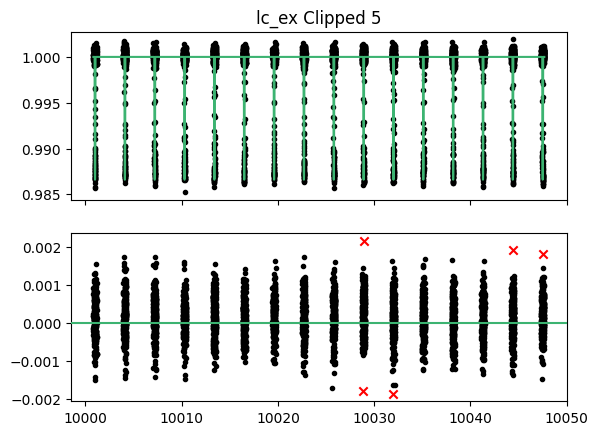


Total points clipped:
All light curves: 5
lc_ex: 5

Initial parameters after optimization:
{'log(P) 1': 1.1314273777765933, 'Tc 1': 10000.999415826767, 'ror 1': 0.10575962375073249, 'log(a/rs) 1': 2.5385488977808404, 'cos(i) 1': 0.009181104443053943, 'log(K) 1': 4.9522349900580185, 'secw 1': 0.0664075325176078, 'sesw 1': 0.13011502511244974, 'F0 lc_ex': 1.0000447086996989, 'gamma': 6.0944191948913285e-05}

Running MCMC burn-in.


  0%|          | 0/20000 [00:00<?, ?it/s]


Running MCMC sampling.


  0%|          | 0/10000 [00:00<?, ?it/s]


Gelman-Rubin Statistics:
log(P) 1 1.0225256240312899
Tc 1 1.014003265499185
ror 1 1.0499686712195242
log(a/rs) 1 1.065086594393049
cos(i) 1 1.0557763876261599
log(K) 1 1.0237216040994104
secw 1 1.0347369995581823
sesw 1 1.027995580609135
F0 lc_ex 1.0194698175107624
gamma 1.0190100131808473


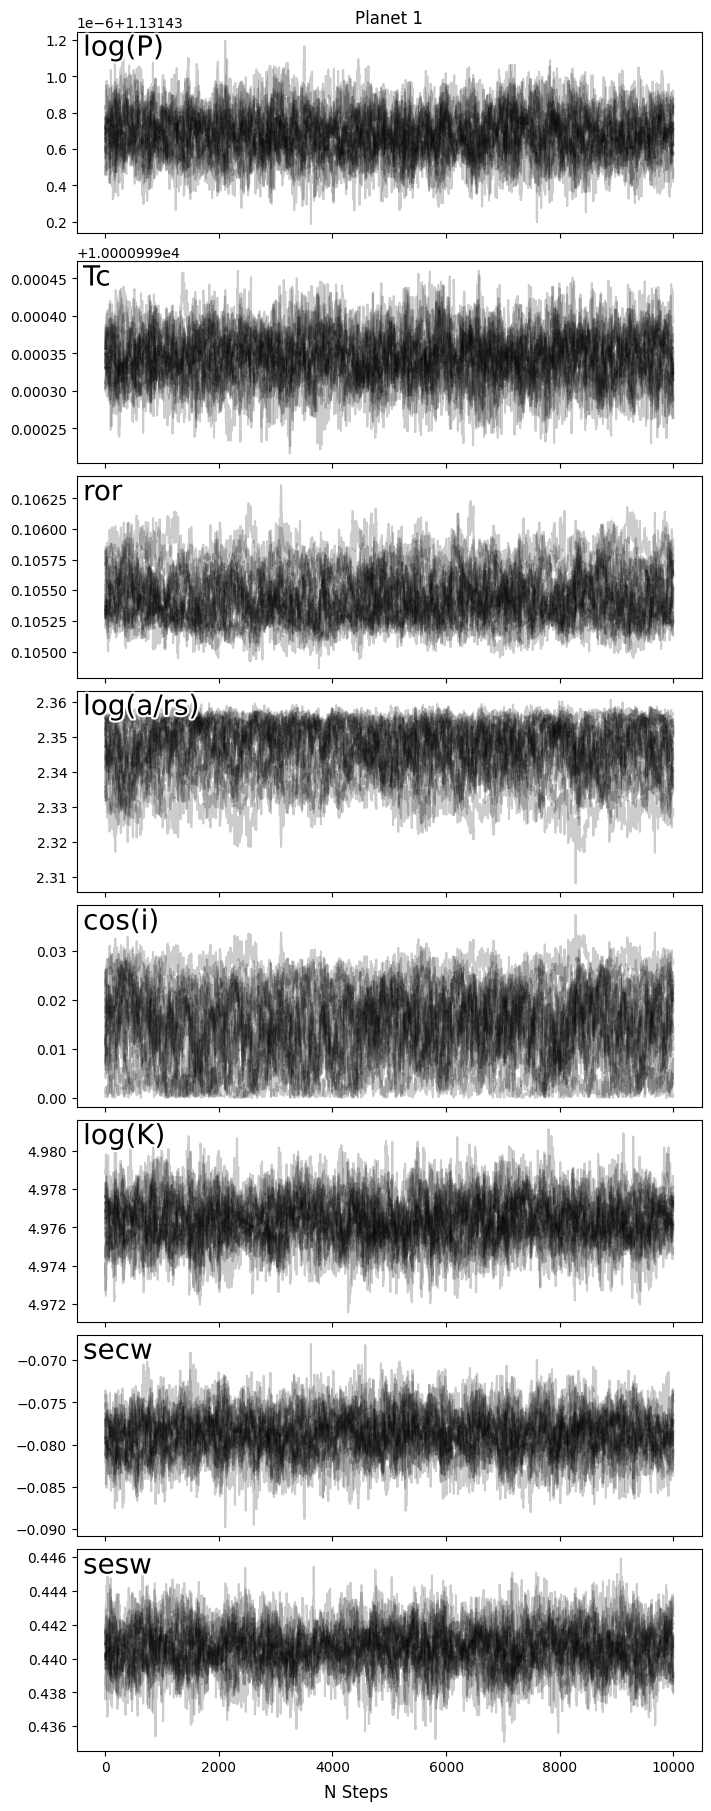

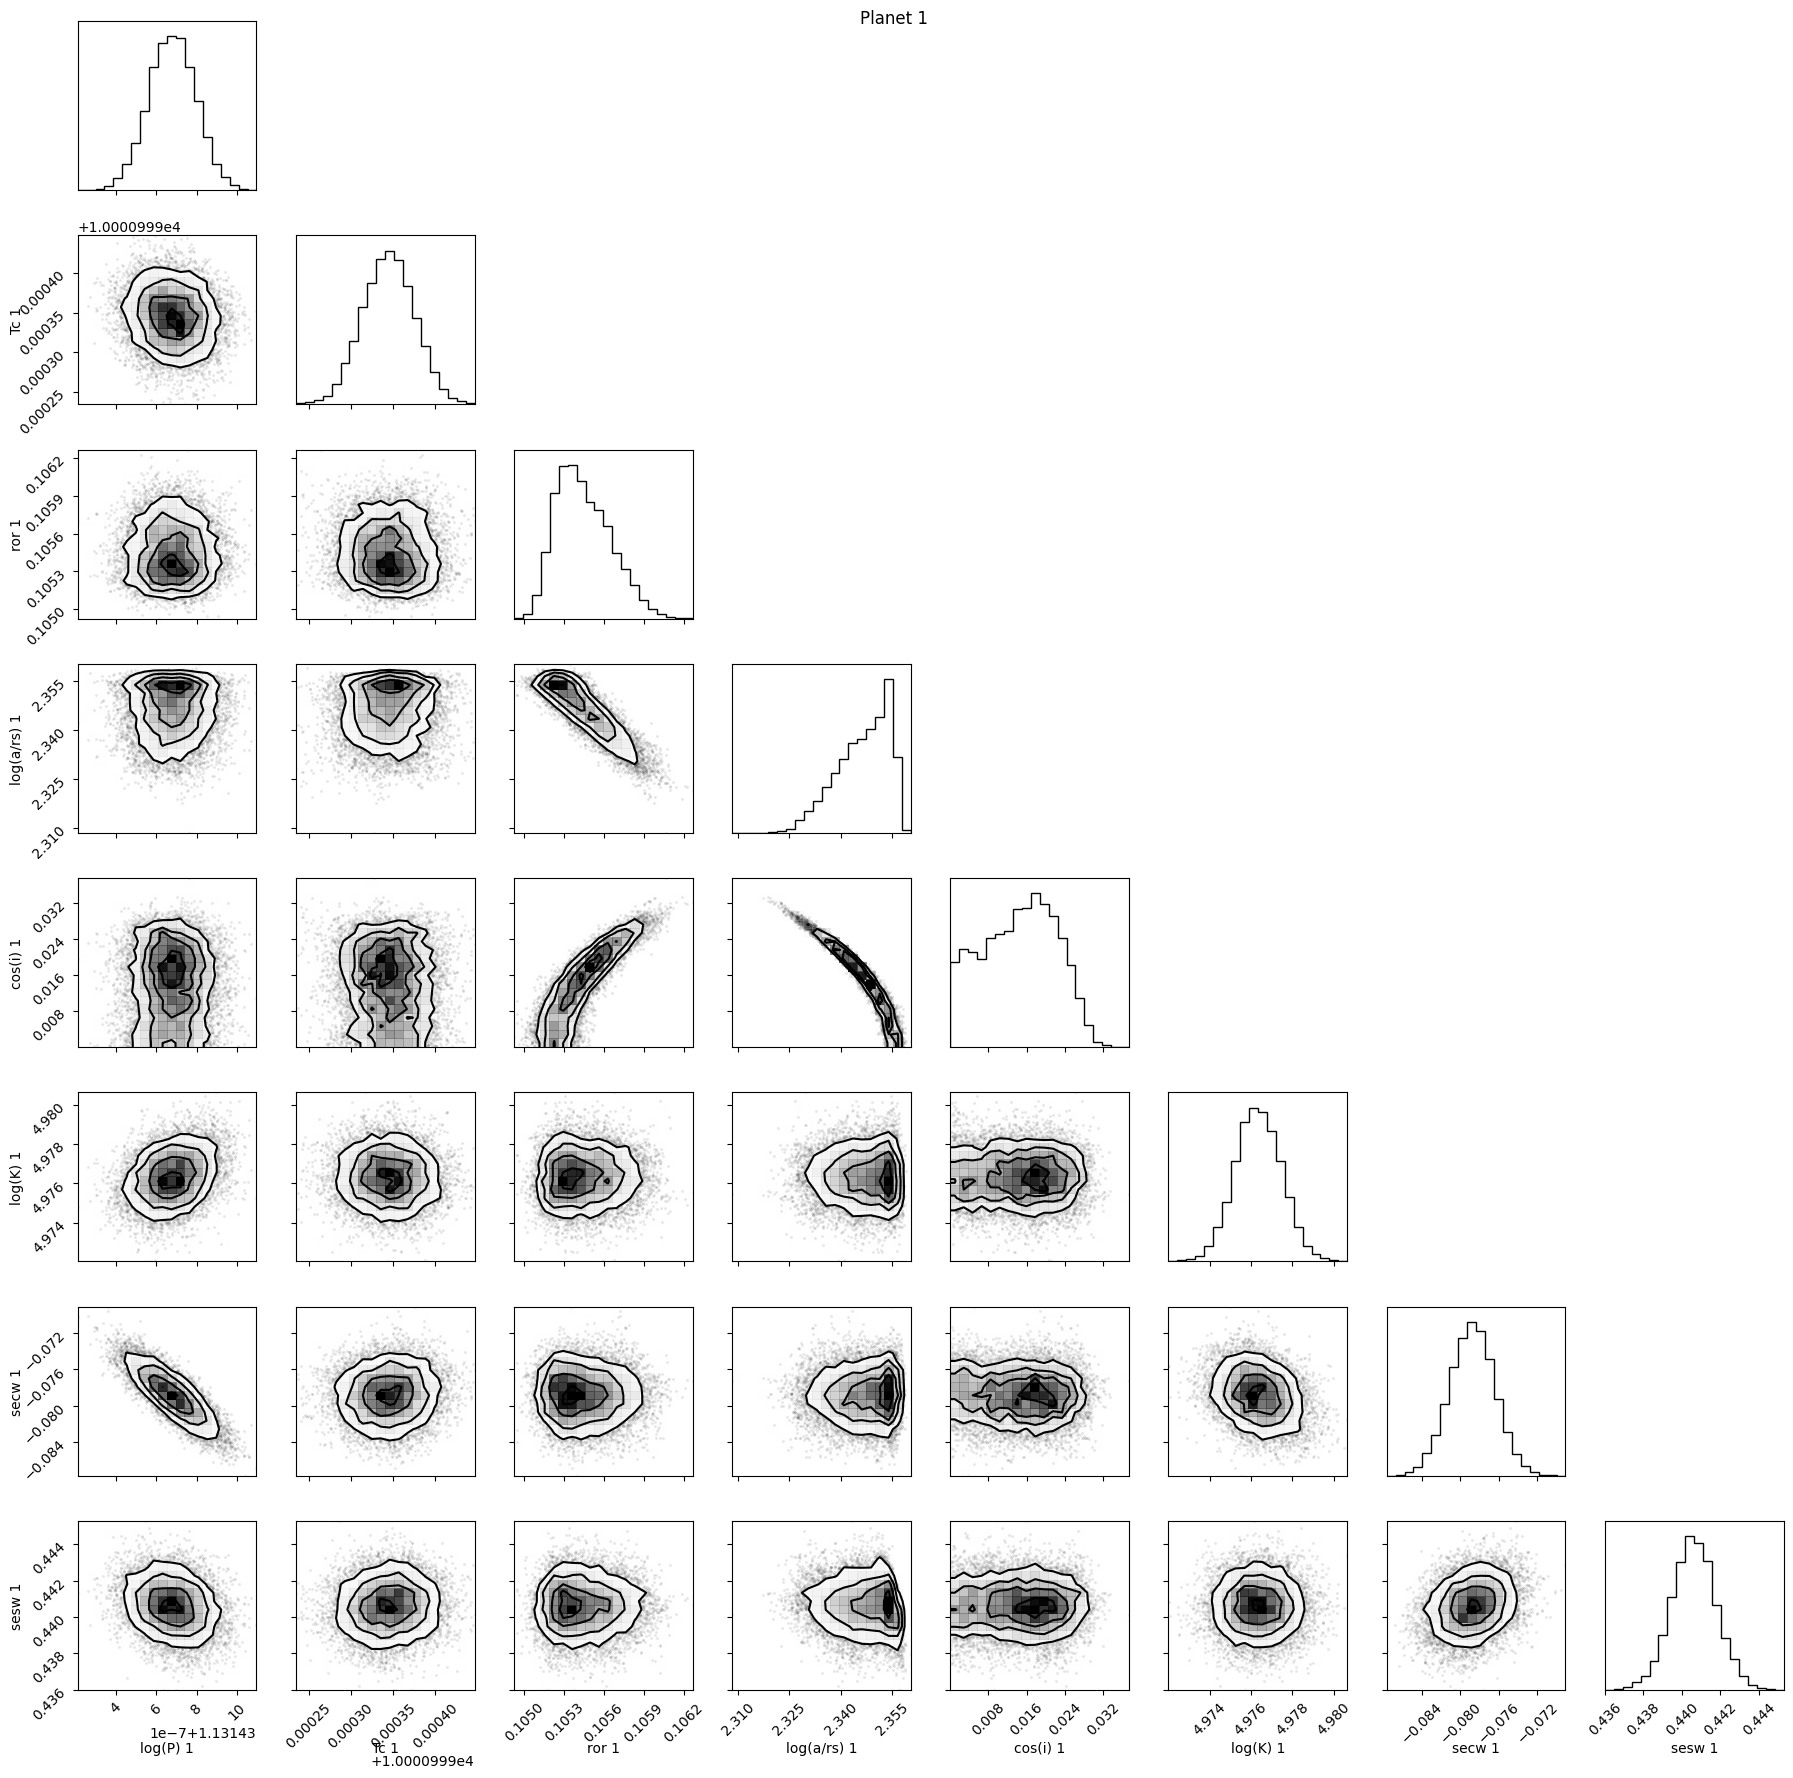


Generating light curves for plots.

Phase folded:

TESS:


  0%|          | 0/1000 [00:00<?, ?it/s]

Full:

lc_ex:


  0%|          | 0/1000 [00:00<?, ?it/s]

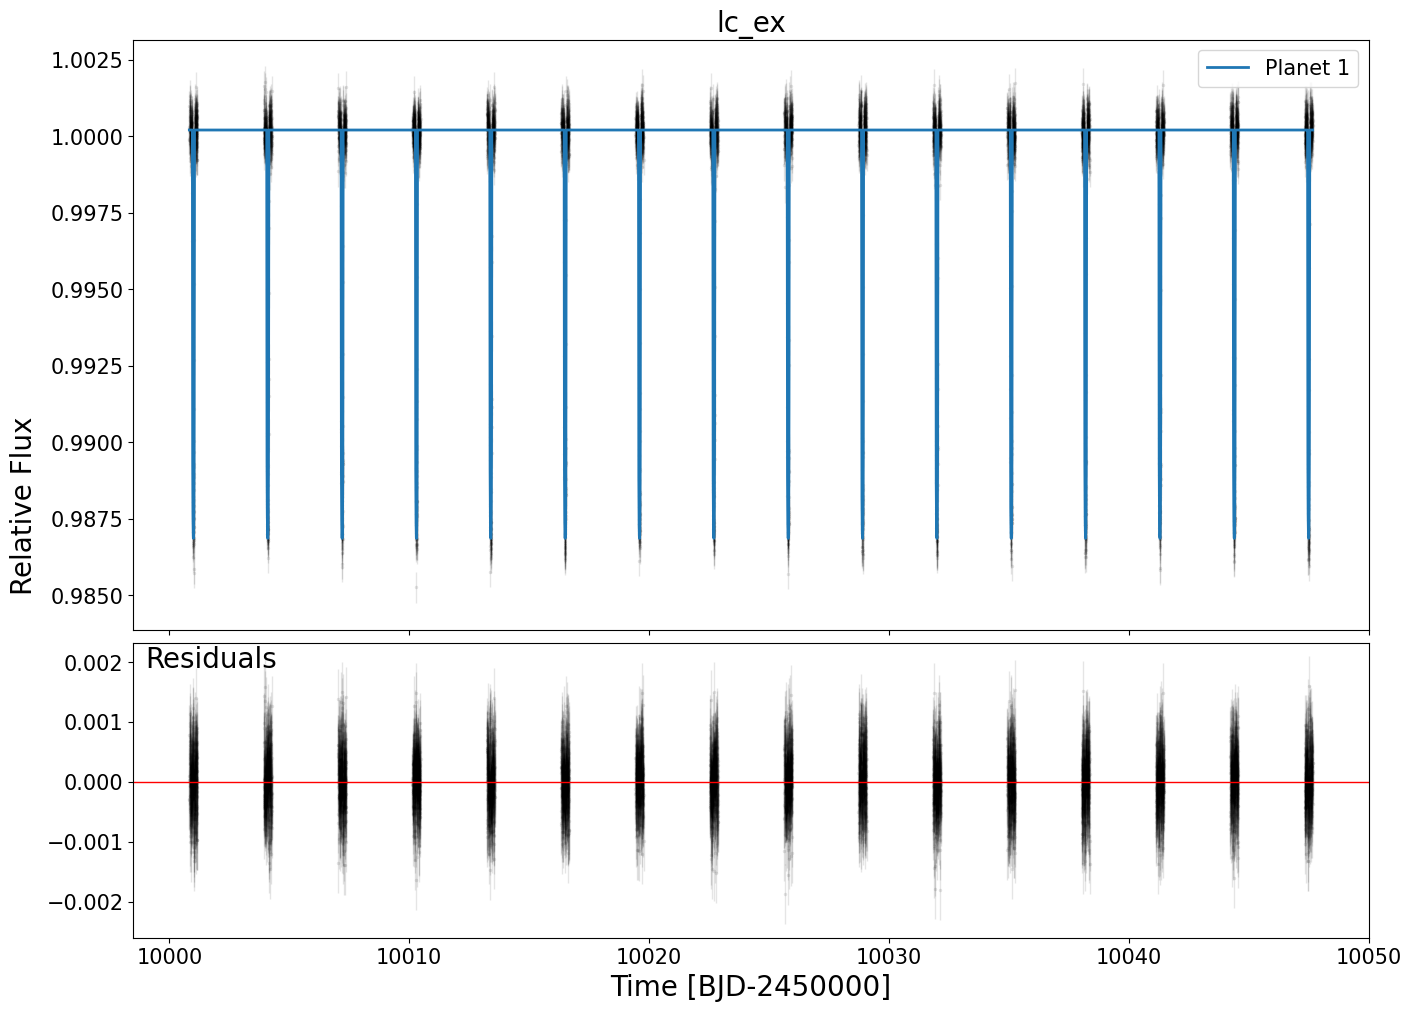

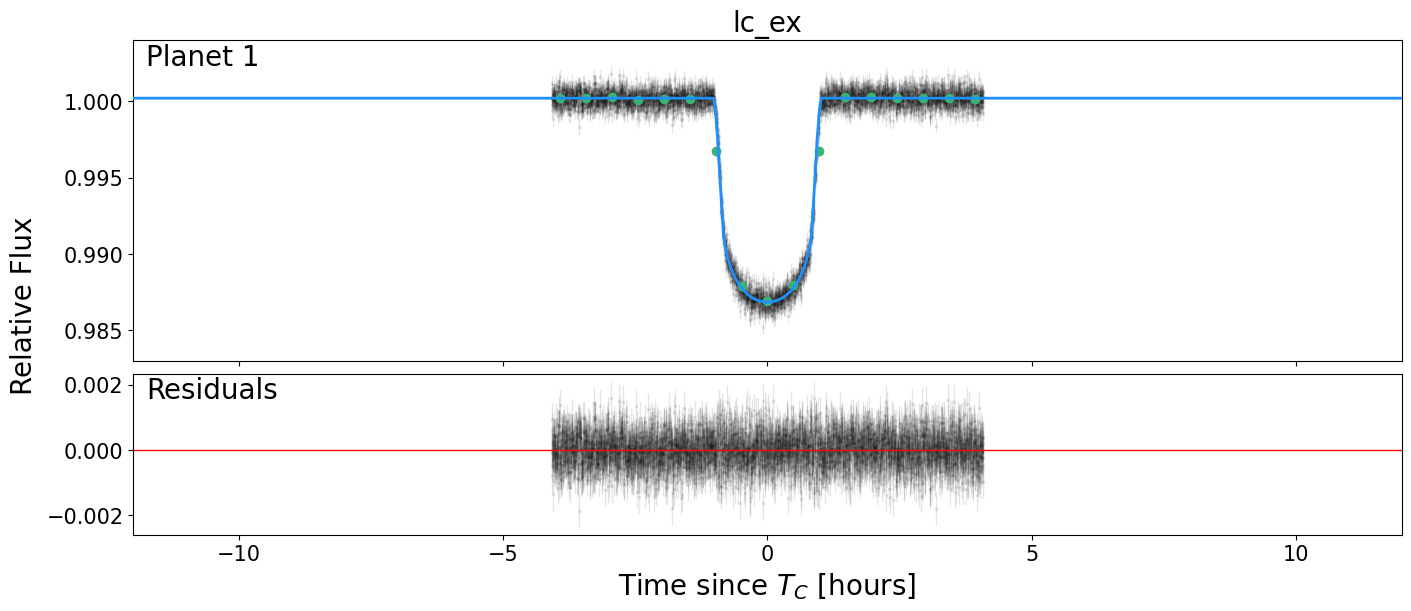


Generating RV models for plots.


  0%|          | 0/10000 [00:00<?, ?it/s]

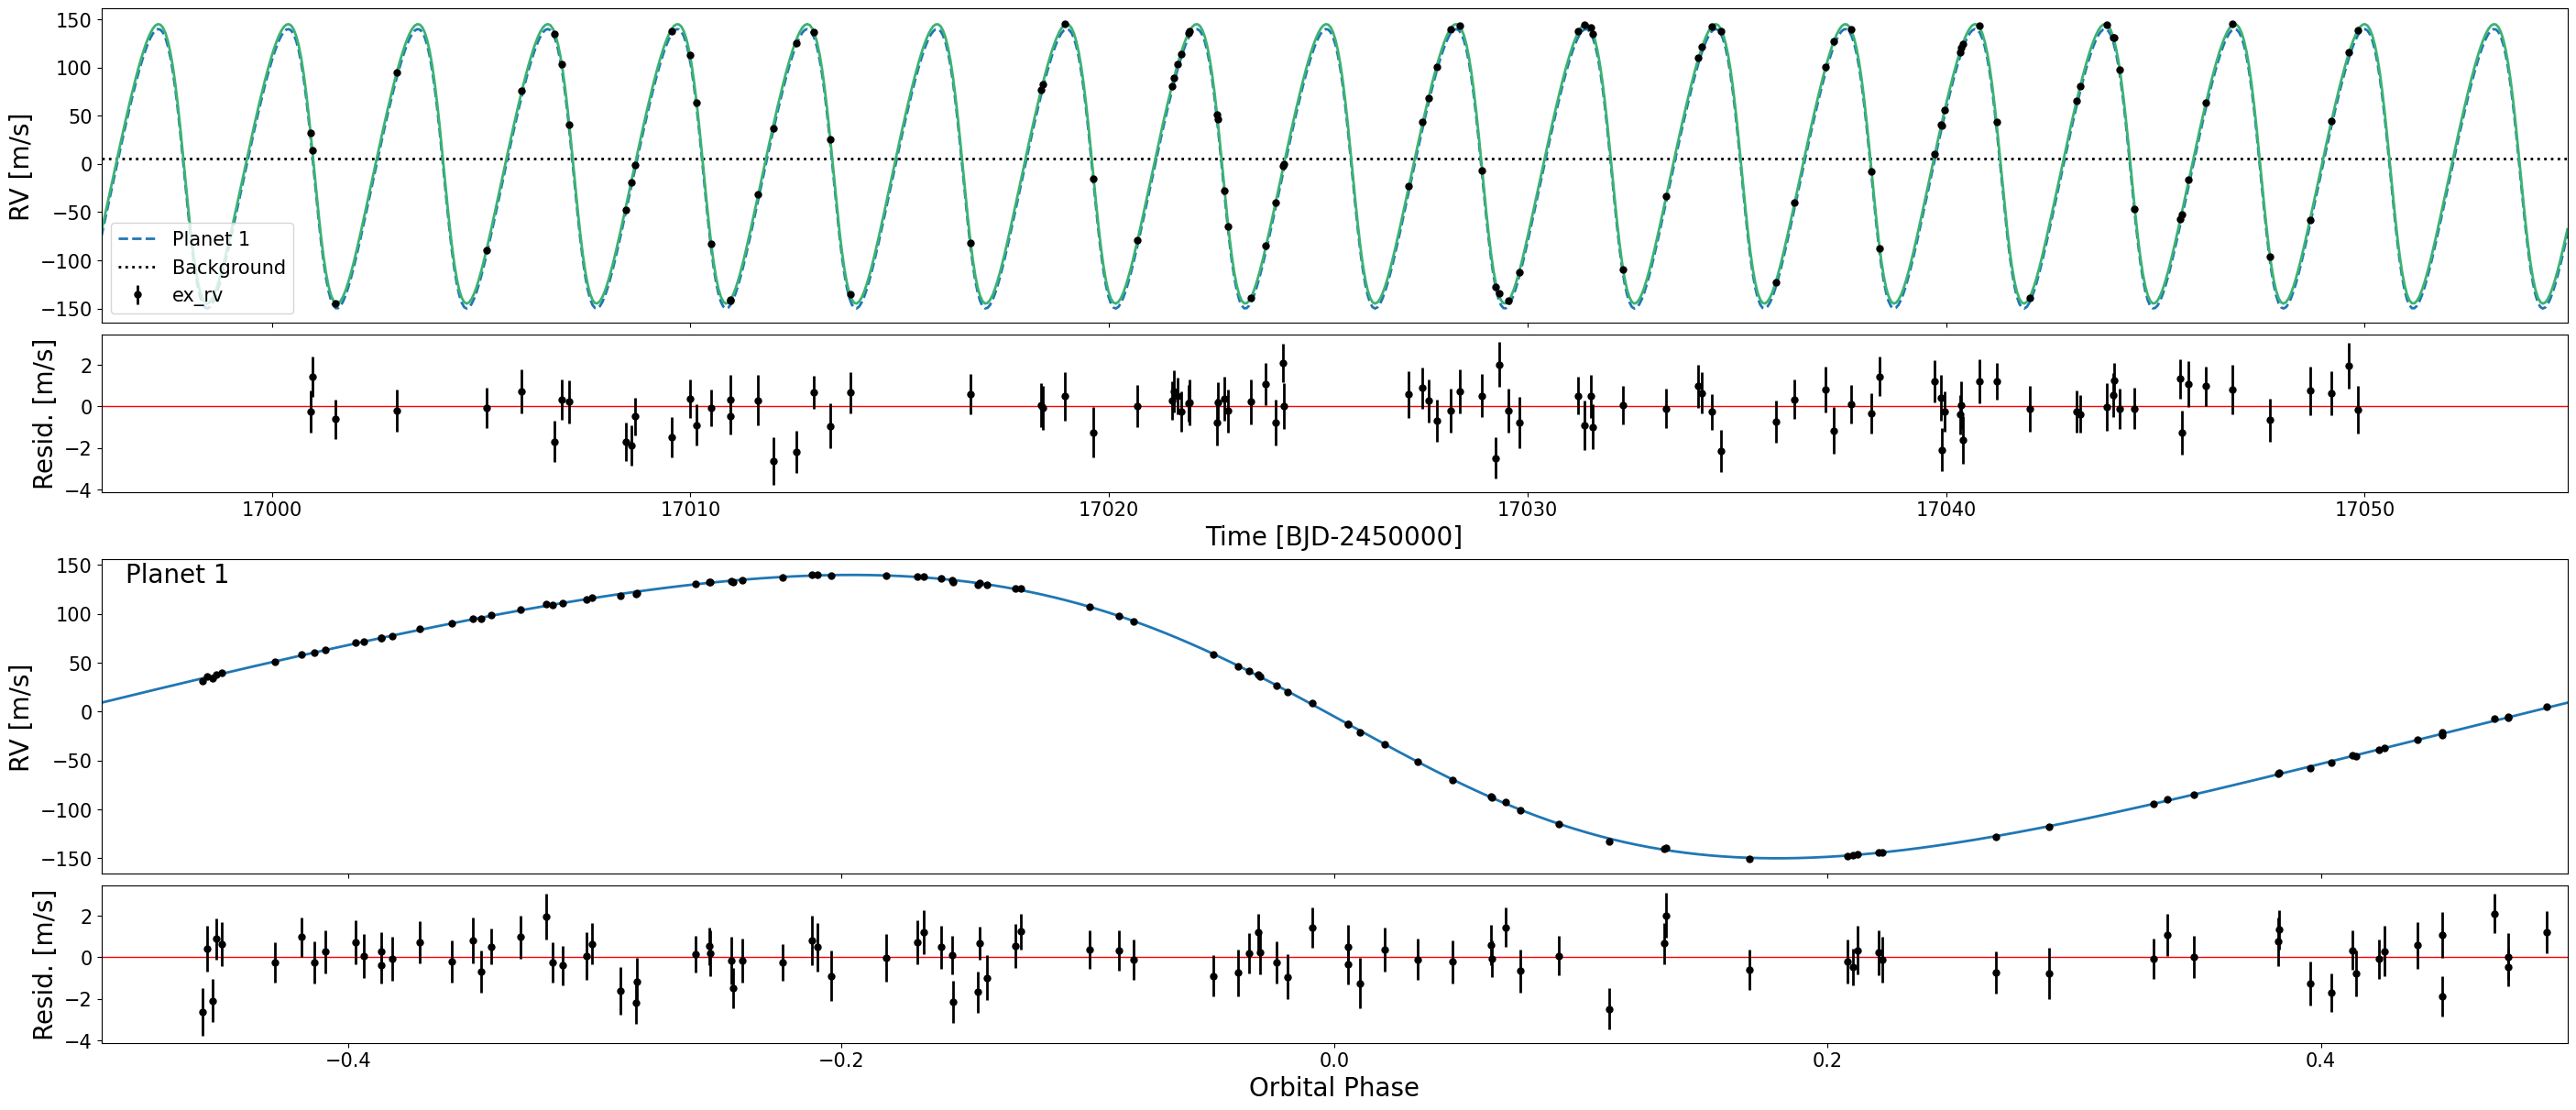


 Parameter     Units           Median                -Error                 +Error        
                                                                                          
----------- ----------- -------------------- ---------------------- ----------------------
   log(P) 1        days    1.131430679569278 1.1514158804182273e-07 1.1551124456943285e-07
       Tc 1 BJD-2450000   10000.999344961538  3.157014725729823e-05 3.0202209018170834e-05
      ror 1              0.10542002569729468 0.00017490609395497125 0.00024244531252702595
log(a/rs) 1                2.347607543147582    0.00957165761892309   0.006602851061133119
   cos(i) 1             0.014975577430631267   0.009519301873437292  0.0075648886230023395
   log(K) 1         m/s    4.976332039030698  0.0010789434262106212  0.0011263324240431416
     secw 1             -0.07875200469279009  0.0023539454833320372   0.002257397025001759
     sesw 1              0.44061241995448686  0.0011261842290488655  0.001141898869141011

In [6]:
name = 'example'
exs.fit(name = name, #The name of the run. This will set the names of output files and the plots folder, and allow you to load it back in using the name.
        nburn = 20000, #How many MCMC burn-in steps to run.
        nrun = 10000, #How many actual MCMC run steps to do.
        fit_transit = True, #Whether or not to fit the light curve data.
        fit_rv = True, #Whether or not to fit the RV data.
        fit_star = False, #Whether or not to fit stellar parameters.
)

The fit was sucessful! Now, we will briefly cover everything that ``Alfred`` spit out above.

First, we were told the initial parameters for the fit, based on defaults and the guess we put into init_planets.txt.

Then, ``Alfred`` performed sigma clipping on the light curve data, to get rid of outlier points. It does this at 5 sigma by default, although that is a parameter than can be tuned or turned off. It first tried to optimize the likelihood function with a Nelder-Mead optimizer, then used the new parameters to generate a model. It used this model to find 5 points which were 5 sigma outliers. These are plotted as red x's in the residual of that initialization. Since the number of clipped points was low, a second round of sigma clipping was unnecessary. ``Alfred`` told us how many points were clipped in each data set (we only have one), and all together.

The new best guess at the fit parameters are printed out, after re-running the Nelder-Mead optimizer after sigma clipping. Small distributions of points around these values are used to initialize the MCMC chains.

The MCMC burn-in was run, followed by the actual run steps, which were both tracked with a progress bar (which does not translate to this html page unfortunately). Then, the Gelman-Rubin statistic was printed for each parameter, a measure of how well the chains converged.

We then got a plot of the chains for the planetary parameters, as well as a corner plot for those same parameters. Everything looks to be in order, with some expected degeneracies in some parameters.

``Alfred`` then generated light curve models from the best fit parameters, first making phase-folded models for each filter (we only used TESS), then full models for each data set (we only had "lc_ex"). These were plotted with the data, first as a time-series for each data set, then phase-folded for each data set.

Next, an RV model was generated from the best fit parameters, and plotted both in time and in phase.

Finally, the median, lower 1 sigma (16th percentile), and upper 1 sigma (84th percentile) values were printed out for each fitted parameter, as well as some derived parameters such as the planet mass and equilibrium temperature.

All of these plots can be found in the directory in the Plots/example folder (or whatever name you chose for the run), and this table of values printed at the bottom can be found as example.txt (again, this will be different if you used a different name) in the Results folder.

If you would like to re-make certain plots, or otherwise fiddle with the data or results, this run can be loaded in the future by re-initializing an ``ExoSystem`` object in the directory and running:

In [ ]:
exs.load_results(name)